In [10]:
#%pip install -r ../requirements.txt -q

# Logistic Regression

In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, average_precision_score

# Load dataset
CSV_PATH = "../data/raw/financial-fraud-detection-dataset/Synthetic_Financial_datasets_log.csv"

df = pd.read_csv(CSV_PATH)

# Drop irrelevant columns
df = df.drop(["nameOrig", "nameDest", "newbalanceOrig", "newbalanceDest","step"], axis=1)

# Encode categorical variable
le = LabelEncoder()
df["type"] = le.fit_transform(df["type"])

# Define features and target
X = df.drop("isFraud", axis=1)
y = df["isFraud"]

# Train-test split (stratified to preserve class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [12]:

# Train logistic regression
model = LogisticRegression(max_iter=1000, class_weight='balanced', solver='liblinear')
model.fit(X_train, y_train)

# Predictions and probabilities
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

# Evaluate metrics
f1 = f1_score(y_test, y_pred)
pr_auc = average_precision_score(y_test, y_pred_prob)

print(f"F1-score: {f1:.4f}")
print(f"PR-AUC:   {pr_auc:.4f}")



F1-score: 0.0107
PR-AUC:   0.0185


## Generate and Save Plots to plots/ Directory

In [13]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve
import numpy as np

# Create plots directory if it doesn't exist
plots_dir = "../plots"
os.makedirs(plots_dir, exist_ok=True)

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

### 1. Confusion Matrix

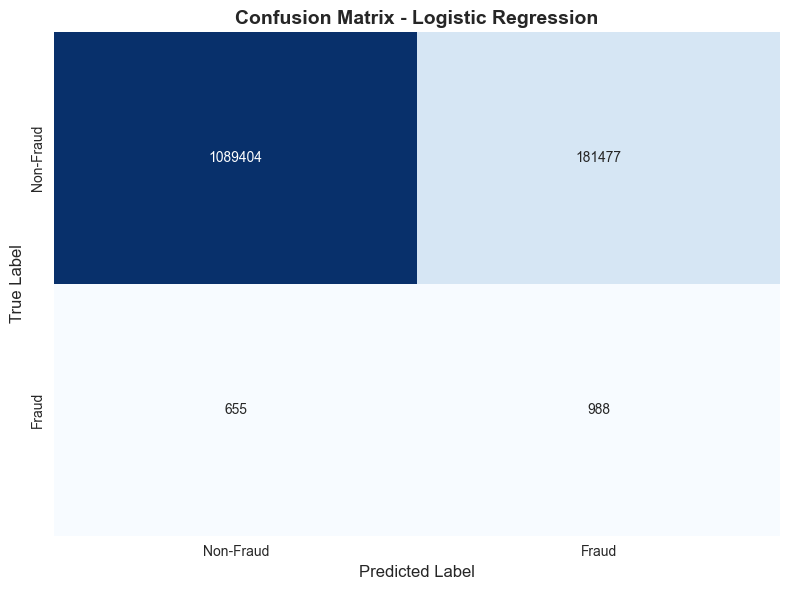

✓ Saved: logistic_regression_confusion_matrix.png


In [14]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['Non-Fraud', 'Fraud'], 
            yticklabels=['Non-Fraud', 'Fraud'])
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix - Logistic Regression', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'logistic_regression_confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: logistic_regression_confusion_matrix.png")

### 2. ROC Curve

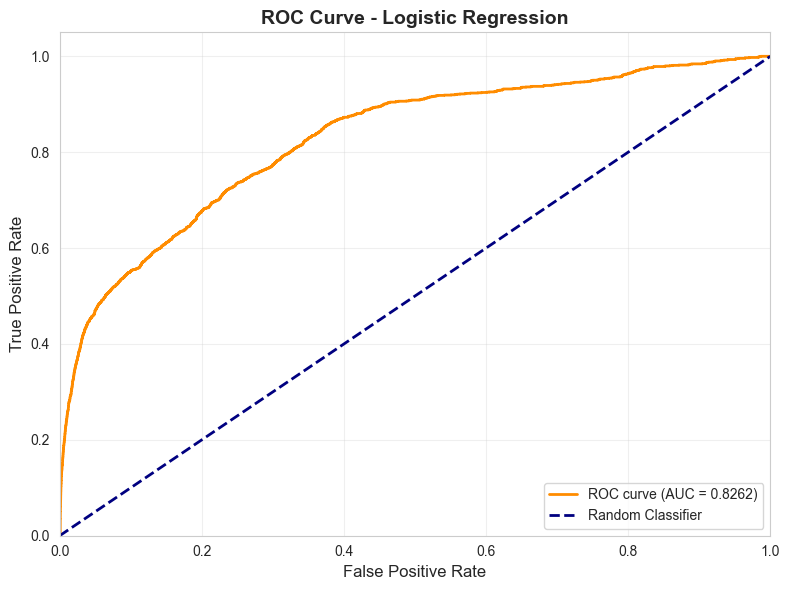

✓ Saved: logistic_regression_roc_curve.png


In [15]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve - Logistic Regression', fontsize=14, fontweight='bold')
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'logistic_regression_roc_curve.png'), dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: logistic_regression_roc_curve.png")

### 3. Precision-Recall Curve

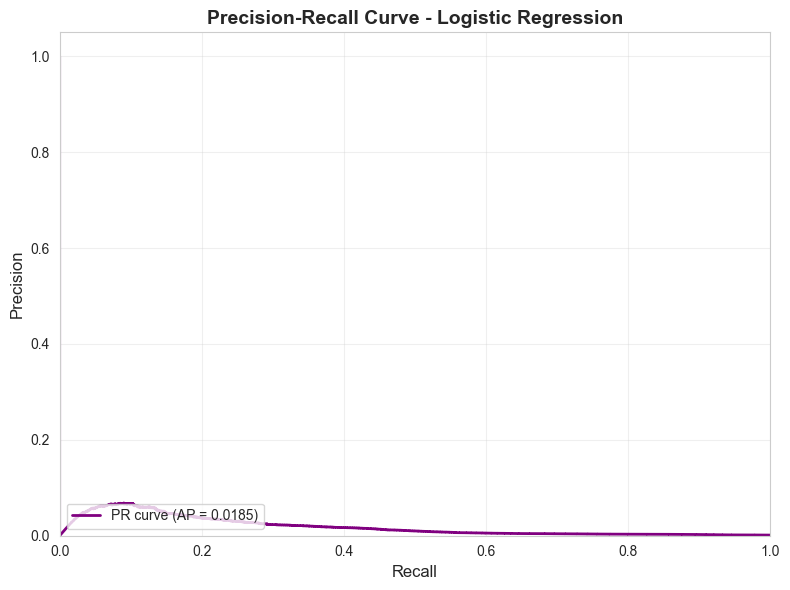

✓ Saved: logistic_regression_pr_curve.png


In [16]:
# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recall, precision, color='purple', lw=2, label=f'PR curve (AP = {pr_auc:.4f})')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve - Logistic Regression', fontsize=14, fontweight='bold')
ax.legend(loc="lower left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'logistic_regression_pr_curve.png'), dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: logistic_regression_pr_curve.png")

### 4. Feature Importance (Coefficients)

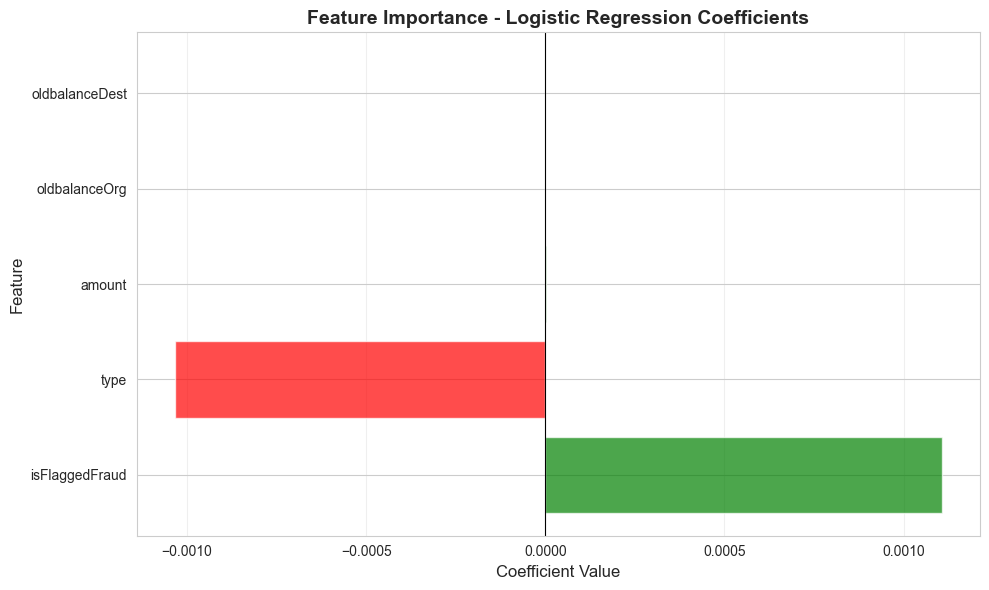

✓ Saved: logistic_regression_feature_importance.png


In [17]:
# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['green' if x > 0 else 'red' for x in feature_importance['Coefficient']]
ax.barh(feature_importance['Feature'], feature_importance['Coefficient'], color=colors, alpha=0.7)
ax.set_xlabel('Coefficient Value', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
ax.set_title('Feature Importance - Logistic Regression Coefficients', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'logistic_regression_feature_importance.png'), dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: logistic_regression_feature_importance.png")

### 5. Save Metrics to CSV

In [18]:
# Save F1 and ROC-AUC to CSV for Streamlit
metrics_data = {
    'Metric': ['F1-Score', 'ROC-AUC'],
    'Value': [
        f1,
        roc_auc,
    ]
}

metrics_df = pd.DataFrame(metrics_data)
metrics_df.to_csv(os.path.join(plots_dir, 'logistic_regression_metrics.csv'), index=False)
print("✓ Saved: logistic_regression_metrics.csv (F1-Score, ROC-AUC)")
print("\nMetrics Summary:")
print(metrics_df.to_string(index=False))

✓ Saved: logistic_regression_metrics.csv (F1-Score, ROC-AUC)

Metrics Summary:
  Metric    Value
F1-Score 0.010733
 ROC-AUC 0.826224
